# Sistemas de recomendación: Book-Crossing

**Integrantes:**
- Abril Iglesias
- Bianca Rizzalli
- Maria Eugenia Arriaga
- Micaela Mendioroz

**Objetivo.** Comparar recomendaciones basadas en popularidad, contenido y filtrado colaborativo, con énfasis en *fairness* entre grupos demográficos y de comportamiento.

Para realizar este trabajo nos basamos en lo que investigamos anteriormente pero en el proceso nos encontramos con que la forma en que lo habiamos pensado tal vez no era la adecuada. A continuacion dejamos el desarrollo del trabajo final donde aclaramos cada parte modificada del plan original.

## Indice
1. Descarga del dataset
2. Preprocesamiento y exploración
    
    2.a. Limpieza de valores nulos

    2.b Histogramas
3. Particionamiento de datos
4. Implementación de los algoritmos

    4.1 Modelos basados en popularidad

    4.2 Filtrado basado en contenido

    4.3 Definicion de grupos

    4.4 Filtrado colaborativo Usuario-Usuario
5. Evaluacion y analisis
    
    5.1 MAE del filtrado colaborativo

    5.2 Metricas de calidad

    5.3 Análisis estadistico y pruebas de hipótesis

    5.4 Fairness
6. Extensiones experimentales
7. Resumen y analisis de resultados
8. Uso de herramientas de IA generativa
    



## 1. Descarga del dataset

Se descargan las tres tablas del repositorio de Book-Crossing solo si todavía no existen localmente.

In [1]:
# %pip usa el mismo Python del kernel (evita el error "pip: command not found").
%pip install numpy pandas matplotlib seaborn scipy scikit-learn nltk ipykernel scikit-surprise

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
from urllib.request import urlretrieve
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

base_url = 'https://raw.githubusercontent.com/ashwanidv100/Recommendation-System---Book-Crossing-Dataset/master/BX-CSV-Dump/'
files = ['BX-Book-Ratings.csv', 'BX-Books.csv', 'BX-Users.csv']

for file_name in files:
    destination = DATA_DIR / file_name
    if not destination.exists():
        print(f'Descargando {file_name}...')
        urlretrieve(base_url + file_name, destination)
    else:
        print(f'{file_name} ya existe')

BX-Book-Ratings.csv ya existe
BX-Books.csv ya existe
BX-Users.csv ya existe


In [3]:
read_options = dict(encoding='latin-1', sep=';', quotechar='"', on_bad_lines='skip', low_memory=False)
ratings = pd.read_csv(DATA_DIR / 'BX-Book-Ratings.csv', **read_options)
books = pd.read_csv(DATA_DIR / 'BX-Books.csv', **read_options)
users = pd.read_csv(DATA_DIR / 'BX-Users.csv', **read_options)

print('ratings:', ratings.shape, '| books:', books.shape, '| users:', users.shape)
display(ratings.head(), books.head(), users.head())

ratings: (1149780, 3) | books: (271360, 8) | users: (278858, 3)


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


## 2. Preprocesamiento y exploración


### Limpieza de valores nulos

En Book-Crossing, un rating igual a `0` representa que el usuario no tuvo interaccion alguna, no cargo un raiting. Se conserva por separado, pero para entrenar y evaluar predicciones se usan ratings de 1 a 10. 

Las edades imposibles se consideran faltantes y los verdaderos valores faltantes no los imputamos para no generar falsa información, luego a la hora de agrupar por edad hicimos un grupo especial para los NaN.

In [4]:
def missing_report(df):
    return (df.isna().mean().mul(100)
              .rename('missing_%')
              .to_frame()
              .sort_values('missing_%', ascending=False))

print('Nulos en ratings')
display(missing_report(ratings))
print('Nulos en books')
display(missing_report(books))
print('Nulos en users')
display(missing_report(users))

# Normalización y deduplicación
ratings = ratings.drop_duplicates(['User-ID', 'ISBN'], keep='last').copy()
books = books.drop_duplicates('ISBN', keep='first').copy()
users = users.drop_duplicates('User-ID', keep='first').copy()

users['Age'] = pd.to_numeric(users['Age'], errors='coerce')
users.loc[~users['Age'].between(5, 100), 'Age'] = np.nan
users['Country'] = (users['Location'].fillna('unknown')
                     .str.rsplit(',', n=1).str[-1]
                     .str.strip().str.lower()
                     .replace('', 'unknown'))
books['Book-Title'] = books['Book-Title'].fillna('')
books['Book-Author'] = books['Book-Author'].fillna('Desconocido')

explicit_ratings = ratings.loc[ratings['Book-Rating'].between(1, 10)].copy()
print(f'Ratings explícitos: {len(explicit_ratings):,} de {len(ratings):,}')

Nulos en ratings


,missing_%
User-ID,0.0
ISBN,0.0
Book-Rating,0.0


Nulos en books


,missing_%
Image-URL-L,0.001106
Book-Author,0.000737
Publisher,0.000737
ISBN,0.000000
Year-Of-Publication,0.000000
Book-Title,0.000000
Image-URL-S,0.000000
Image-URL-M,0.000000


Nulos en users


,missing_%
Age,39.719857
User-ID,0.000000
Location,0.000000


Ratings explícitos: 433,671 de 1,149,780


### Histogramas

Graficamos por un lado los ratings reales (es decir de 1 a 10), y por otro la distribucion de las edades, utilizando 30 bins para ver su distribucion real y luego poder decidir como formar los grupos.

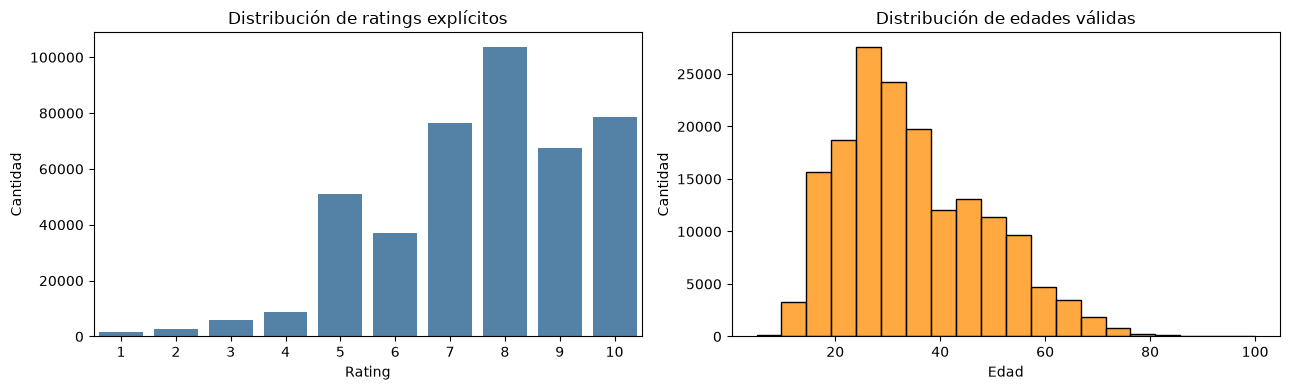

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=explicit_ratings, x='Book-Rating', ax=axes[0], color='steelblue')
axes[0].set(title='Distribución de ratings explícitos', xlabel='Rating', ylabel='Cantidad')
sns.histplot(users['Age'].dropna(), bins=20, ax=axes[1], color='darkorange')
axes[1].set(title='Distribución de edades válidas', xlabel='Edad', ylabel='Cantidad')
plt.tight_layout()
plt.show()

## 3. Particionamiento de los datos

Se realiza un *holdout* 70/30 por usuario. Se divide para cada usuario una parte de sus ratings para train y otra para test, de esta forma solo entran usuarios con al menos dos ratings explícitos para que ambos conjuntos tengan información. Este particionamiento se reutiliza en los modelos personalizados y evita evaluar con datos vistos durante el entrenamiento.

In [6]:
def split_by_user(df, train_fraction=0.70, seed=42):
    rng = np.random.default_rng(seed)
    train_indices, test_indices = [], []
    for _, group in df.groupby('User-ID'):
        if len(group) < 2:
            continue
        indices = group.index.to_numpy().copy()
        rng.shuffle(indices)
        cut = min(max(1, int(len(indices) * train_fraction)), len(indices) - 1)
        train_indices.extend(indices[:cut])
        test_indices.extend(indices[cut:])
    return df.loc[train_indices].copy(), df.loc[test_indices].copy()

train_ratings, test_ratings = split_by_user(explicit_ratings, seed=RANDOM_STATE)
print('Train:', train_ratings.shape, '| Test:', test_ratings.shape)
assert set(train_ratings.index).isdisjoint(test_ratings.index)

Train: (258302, 3) | Test: (129987, 3)


## 4. Implementación de los algoritmos

### 4.1 Modelos basados en popularidad

Primero se construye `data` con los nombres de columnas. Los promedios y conteos se calculan únicamente con ratings explícitos.

In [7]:
book_statistics = (explicit_ratings.groupby('ISBN')['Book-Rating']
                   .agg(average_rating='mean', ratings_count='count')
                   .reset_index())

data = (books[['ISBN', 'Book-Title', 'Book-Author']]
        .merge(book_statistics, on='ISBN', how='inner')
        .rename(columns={'Book-Title': 'title', 'Book-Author': 'authors'}))

data[['title', 'authors', 'average_rating', 'ratings_count']].head()

,title,authors,average_rating,ratings_count
0,Clara Callan,Richard Bruce Wright,7.666667,9
1,Decision in Normandy,Carlo D'Este,7.500000,2
2,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,7.833333,6
3,The Kitchen God's Wife,Amy Tan,8.176471,17
4,What If?: The World's Foremost Military Histor...,Robert Cowley,8.000000,1


#### Promedio de ratings

In [8]:
# Ordeno de mayor a menor por promedio de ratings para luego recomendar los 10 primeros
top_rating = data.sort_values(
    by='average_rating',
    ascending=False
)

top_rating[['title', 'authors', 'average_rating', 'ratings_count']].head(10)

,title,authors,average_rating,ratings_count
40151,The Empire's Old Clothes: What the Lone Ranger...,Ariel Dorfman,10.0,1
40170,Unraveled,C. J. Barry,10.0,1
40086,"Simple Encounters: Stories of life, laughter, ...",Chris Clarke-Epstein,10.0,1
40097,NOTE FOUND IN A BOTTLE,Susan Cheever,10.0,1
40197,Dreaming of You,Lisa Kleypas,10.0,2
40198,"How to Host a Seduction (Harlequin Blaze, No 80)",Jeanie London,10.0,1
149742,Sports picture quiz book: With 240 photographs...,John Grafton,10.0,1
149743,The It's a Wonderful Life Trivia Book,Jimmy Hawkins,10.0,1
149745,The Ultimate Book of Sports Lists,Andrew Postman,10.0,1
149746,Good Natured: The Origins of Right and Wrong i...,F. B. M. De Waal,10.0,1


#### Ranking con umbral de significancia

In [9]:
min_votos = 100

top_populares = data[data['ratings_count'] >= min_votos]

top_populares = top_populares.sort_values(
    by='average_rating',
    ascending=False
)

top_populares[['title','authors','average_rating','ratings_count']].head(10)

,title,authors,average_rating,ratings_count
4718,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,9.262774,137
5487,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,9.082707,133
3339,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,9.035461,141
4785,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,9.033981,206
2467,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,8.983193,119
5980,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,8.954545,110
30,To Kill a Mockingbird,Harper Lee,8.943925,214
1868,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,8.939297,313
4719,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,8.920635,126
1378,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. TOLKIEN,8.839695,131


#### Fórmula IMDb

In [10]:
# Función dada en la práctica
def return_best_n(statistics, n, column):
    statistics = pd.DataFrame(statistics)
    return statistics.sort_values(by=column, axis=0, ascending=False).iloc[:n]

averages = data['average_rating']
counts = data['ratings_count']
minimum = data['ratings_count'].quantile(0.7)
general_average = data['average_rating'].mean()  # C

data['IMDb Metric'] = (data['average_rating'] * data['ratings_count'] + general_average * minimum) / (data['ratings_count'] + minimum)

best = return_best_n(data, 10, 'IMDb Metric')
best[['title', 'authors', 'average_rating', 'ratings_count', 'IMDb Metric']]

,title,authors,average_rating,ratings_count,IMDb Metric
56430,Harry Potter and the Chamber of Secrets Postca...,J. K. Rowling,9.869565,23,9.682203
5101,Postmarked Yesteryear: 30 Rare Holiday Postcards,Pamela E. Apkarian-Russell,10.000000,11,9.619622
47181,Dilbert: A Book of Postcards,Scott Adams,9.923077,13,9.603672
10818,"The Two Towers (The Lord of the Rings, Part 2)",J. R. R. Tolkien,9.720000,25,9.557596
11252,The Giving Tree,Shel Silverstein,9.750000,20,9.547958
54320,The Sneetches and Other Stories,Dr. Seuss,10.000000,8,9.505509
8568,Fox in Socks (I Can Read It All by Myself Begi...,Dr. Seuss,9.785714,14,9.503443
35395,Natural California: A Postcard Book,Not Applicable (Na ),10.000000,7,9.450565
17882,Uncle John's Supremely Satisfying Bathroom Rea...,Bathroom Readers Institute,10.000000,7,9.450565
12770,Calvin and Hobbes,Bill Watterson,9.583333,24,9.425196


### 4.2 Filtrado basado en contenido


Realizamos un preprocesamiento para la tecnica de filtrado por contenido:
- Combinar título, autor y año de publicación (Tomar los atributos importantes)
- Normalizar el texto 
- Remover *stop-words*
- Aplicar *stemming* usando NLTK 
- Vectorizar con `CountVectorizer`. 

Para evitar construir una matriz cuadrada enorme, la búsqueda usa vecinos más cercanos con distancia coseno sobre una muestra de libros con interacciones.

In [11]:
try:
    from nltk.stem.snowball import SnowballStemmer
    stemmer = SnowballStemmer('english')
    stem_word = stemmer.stem
except ImportError:
    print('NLTK no está instalado: se continúa sin stemming.')
    stem_word = lambda word: word

stop_words = set(ENGLISH_STOP_WORDS)

def text_analyzer(text):
    tokens = re.findall(r'[a-záéíóúüñ]+', str(text).lower())
    return [stem_word(token) for token in tokens if token not in stop_words and len(token) > 1]

# Límite ajustable para que la notebook pueda ejecutarse en una computadora personal.
MAX_CONTENT_BOOKS = 30_000
content_books = (data.sort_values('ratings_count', ascending=False)
                 .head(MAX_CONTENT_BOOKS)
                 .drop_duplicates('ISBN')
                 .reset_index(drop=True)
                 .copy())
content_books['text'] = content_books['title'] + ' ' + content_books['authors']

vectorizer = CountVectorizer(analyzer=text_analyzer, max_features=15_000)
content_matrix = vectorizer.fit_transform(content_books['text'])
content_model = NearestNeighbors(metric='cosine', algorithm='brute', n_jobs=-1)
content_model.fit(content_matrix)
print('Matriz de contenido:', content_matrix.shape)

Matriz de contenido: (30000, 15000)


In [12]:
def recommend_similar_books(title, n=10):
    matches = content_books.index[content_books['title'].str.contains(title, case=False, regex=False)]
    if len(matches) == 0:
        raise ValueError(f'No se encontró un libro que contenga: {title!r}')
    book_idx = matches[0]
    n_neighbors = min(n + 1, len(content_books))
    distances, indices = content_model.kneighbors(content_matrix[book_idx], n_neighbors=n_neighbors)
    result = content_books.iloc[indices[0]].copy()
    result['similarity'] = 1 - distances[0]
    return result.iloc[1:][['ISBN', 'title', 'authors', 'similarity']]

def recommend_content_for_user(user_id, n=10, positive_threshold=7):
    liked = train_ratings.loc[
        (train_ratings['User-ID'] == user_id) &
        (train_ratings['Book-Rating'] >= positive_threshold), 'ISBN'
    ]
    seed_indices = content_books.index[content_books['ISBN'].isin(liked)]
    if len(seed_indices) == 0:
        return pd.DataFrame(columns=['ISBN', 'title', 'authors', 'score'])
    query = np.asarray(content_matrix[seed_indices].mean(axis=0))
    distances, indices = content_model.kneighbors(query, n_neighbors=min(n + len(seed_indices), len(content_books)))
    seen = set(train_ratings.loc[train_ratings['User-ID'] == user_id, 'ISBN'])
    result = content_books.iloc[indices[0]].copy()
    result['score'] = 1 - distances[0]
    return result.loc[~result['ISBN'].isin(seen), ['ISBN', 'title', 'authors', 'score']].head(n)

# Ejemplo por título
recommend_similar_books('Harry Potter', n=10)

,ISBN,title,authors,similarity
102,0590353403,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,0.824958
466,043936213X,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,0.824958
26976,0439554896,Harry Potter and the Chamber of Secrets (Harry...,J. K. Rowling,0.783349
10723,043965548X,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling,0.783349
13572,2070518426,Harry Potter a l'ecole des sorciers,J. K. Rowling,0.721688
12125,0807281956,Harry Potter and the Sorcerer's Stone (Book 1 ...,J. K. Rowling,0.714435
16953,2070556859,Harry Potter et l'Ordre du PhÃ©nix (Harry Pott...,J.K. Rowling,0.670820
4635,8478884459,Harry Potter y la piedra filosofal,J. K. Rowling,0.645497
4636,8478884955,Harry Potter y la cÃ¡mara secreta,J. K. Rowling,0.645497
117,0439139600,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,0.645497


Era esperable que leyendo un libro de harry potter te recomiende todos los demas de la saga ya que se compara la similitud usando titulo y autor. Probemos con otro libro

In [13]:
recommend_similar_books('The Giving Tree', n=10)

,ISBN,title,authors,similarity
2046,0060256656,The Giving Tree,Shel Silverstein,1.000000
1105,0060248025,Falling Up,Shel Silverstein,0.577350
21549,0060256680,Where the Sidewalk Ends: The Poems and Drawing...,Shel Silverstein,0.577350
1842,0060256737,A Light in the Attic,Shel Silverstein,0.500000
1424,0060256672,Where the Sidewalk Ends : Poems and Drawings,Shel Silverstein,0.408248
16567,0060256575,The Missing Piece Meets the Big O,Shel Silverstein,0.408248
20518,0060256710,The Missing Piece (Ursula Nordstrom Book),Shel Silverstein,0.377964
9093,067121148X,Uncle Shelby's ABZ Book: A Primer for Adults Only,Shel Silverstein,0.377964
26783,0886777828,"The Dreaming Tree: The Dreamstone, the Tree of...",C. J. Cherryh,0.353553
15366,0312856334,The Tree People (Tree People),Naomi M. Stokes,0.316228


Hace buenas recomendaciones, aunque con pocos atributos solo se puede guiar por el autor, y palabras parecidas en el titulo, como por ejemplo el libro The Tree People (Tree People). Si tuvieramos genero o una descripcion del libro es probable que encontremos recomendaciones mas adecuadas.

Probamos con un ultimo libro:

In [14]:
recommend_similar_books('Natural California: A Postcard Book', n=10)

,ISBN,title,authors,similarity
24159,1574862537,Gooseberry Patch Christmas (Book 4),Not Applicable (Na ),0.500000
10984,3822860867,"Millennium Art (Postcard book, 30 detachable p...",Taschen America,0.433013
17103,1567189644,Llewellyn's 2001 Moon Sign Book and Gardening ...,Not Applicable (Na ),0.433013
9221,0440775825,Ralph S. Mouse,Not Applicable (Na ),0.408248
24754,0307301907,The Poky Little Puppy's First Christmas (A Lit...,Not Applicable (Na ),0.369274
20072,0915473275,"Planning for Pregnancy, Birth, and Beyond",Not Applicable (Na ),0.365148
3510,0836213319,Dilbert: A Book of Postcards,Scott Adams,0.365148
7783,0836228804,Poodles: A Book of Postcards,Andrews McMeel Publishing,0.333333
10700,0821221817,The National Parks : A Postcard Folio Book,Ansel Adams,0.333333
9955,0894718207,Nostalgic Barbie: A Postcard Book,Running Press,0.333333


Vemos que aca hay variedad de autores, y hay libros que tambien son de postcards, por lo que estaria haciendo buenas recomendaciones.

### 4.3 Definición de grupos

Se crean grupos por edad, país e historial. Los países fuera de los más frecuentes se agrupan como `other`. 

In [15]:
interaction_counts = explicit_ratings.groupby('User-ID').size().rename('interaction_count')

#Hacemos un inner join con los usuarios para que solo entren a la tabla los que tengan al menos un rating hecho
user_groups = users.merge(interaction_counts, on='User-ID', how='inner')
user_groups['interaction_count'] = user_groups['interaction_count'].astype(int)

user_groups['age_group'] = pd.cut(
    user_groups['Age'], bins=[4, 17, 29, 44, 64, 100],
    labels=['05-17', '18-29', '30-44', '45-64', '65-100']
).astype('object').fillna('unknown')

top_countries = user_groups.loc[user_groups['Country'] != 'unknown', 'Country'].value_counts().head(10).index
user_groups['country_group'] = np.where(user_groups['Country'].isin(top_countries), user_groups['Country'], 'other')
# Umbral solo entre usuarios evaluables (>=2 ratings): el holdout descarta
# a quienes tienen 0 o 1, así que si la mediana se calcula sobre todos los activos
# (a menudo da 1.0) el grupo "short" nunca aparece en test.
evaluable_counts = user_groups.loc[user_groups['interaction_count'] >= 2, 'interaction_count']
history_threshold = evaluable_counts.median()
user_groups['history_group'] = np.where(
    user_groups['interaction_count'] <= history_threshold, 'short', 'long'
)

print('Umbral de historial:', history_threshold)
display(user_groups[['User-ID', 'age_group', 'country_group', 'history_group', 'interaction_count']].head())

Umbral de historial: 4.0


,User-ID,age_group,country_group,history_group,interaction_count
0,8,unknown,canada,long,7
1,9,unknown,usa,short,1
2,10,18-29,spain,short,1
3,12,unknown,usa,short,1
4,14,unknown,usa,short,3


### 4.4 Filtrado colaborativo Usuario–Usuario

#### Similitud de coseno

Para este filtrado, un agente de IA realizó el código, donde no usa una libreria preexistente, sino que esta hecho a mano. Lo decidimos dejar para aumentar los casos de análisis y poder comparar diferentes modelos.

La implementación utiliza similitud coseno entre usuarios. Para mantener un consumo de memoria razonable se trabaja con los usuarios y libros más activos; estos límites son parámetros explícitos.

In [16]:
MAX_USERS = 5_000
MAX_BOOKS = 5_000
N_NEIGHBORS = 30

active_users = train_ratings['User-ID'].value_counts().head(MAX_USERS).index
active_books = train_ratings.loc[train_ratings['User-ID'].isin(active_users), 'ISBN'].value_counts().head(MAX_BOOKS).index
collab_train = train_ratings[
    train_ratings['User-ID'].isin(active_users) & train_ratings['ISBN'].isin(active_books)
].copy()

user_ids = pd.Index(collab_train['User-ID'].unique(), name='User-ID')
book_ids = pd.Index(collab_train['ISBN'].unique(), name='ISBN')
user_to_idx = pd.Series(np.arange(len(user_ids)), index=user_ids)
book_to_idx = pd.Series(np.arange(len(book_ids)), index=book_ids)
rows = collab_train['User-ID'].map(user_to_idx).to_numpy()
cols = collab_train['ISBN'].map(book_to_idx).to_numpy()
values = collab_train['Book-Rating'].astype(float).to_numpy()
user_item = csr_matrix((values, (rows, cols)), shape=(len(user_ids), len(book_ids)))

user_means = np.asarray(user_item.sum(axis=1)).ravel() / np.maximum(user_item.getnnz(axis=1), 1)
centered_values = values - user_means[rows]
centered_matrix = csr_matrix((centered_values, (rows, cols)), shape=user_item.shape)

user_model = NearestNeighbors(metric='cosine', algorithm='brute', n_jobs=-1)
user_model.fit(centered_matrix)
k = min(N_NEIGHBORS + 1, len(user_ids))
neighbor_distances, neighbor_indices = user_model.kneighbors(centered_matrix, n_neighbors=k)
neighbor_similarities = 1 - neighbor_distances
print('Matriz usuario–libro:', user_item.shape, '| ratings:', user_item.nnz)

Matriz usuario–libro: (4618, 5000) | ratings: 55401


In [17]:
def predict_user_user(user_id, isbn):
    if user_id not in user_to_idx.index or isbn not in book_to_idx.index:
        return float(explicit_ratings['Book-Rating'].mean())
    u = int(user_to_idx[user_id])
    i = int(book_to_idx[isbn])
    neighbors = neighbor_indices[u, 1:]
    similarities = neighbor_similarities[u, 1:]
    neighbor_ratings = user_item[neighbors, i].toarray().ravel()
    rated = neighbor_ratings > 0
    if not rated.any() or np.abs(similarities[rated]).sum() == 0:
        return float(user_means[u])
    deviations = neighbor_ratings[rated] - user_means[neighbors[rated]]
    prediction = user_means[u] + np.dot(similarities[rated], deviations) / np.abs(similarities[rated]).sum()
    return float(np.clip(prediction, 1, 10))

def recommend_user_user(user_id, n=10):
    if user_id not in user_to_idx.index:
        return pd.DataFrame(columns=['ISBN', 'title', 'authors', 'prediction'])
    u = int(user_to_idx[user_id])
    seen = set(collab_train.loc[collab_train['User-ID'] == user_id, 'ISBN'])
    candidates = [isbn for isbn in book_ids if isbn not in seen]
    scores = np.array([predict_user_user(user_id, isbn) for isbn in candidates])
    top = np.argsort(scores)[-n:][::-1]
    result = pd.DataFrame({'ISBN': np.array(candidates)[top], 'prediction': scores[top]})
    return result.merge(data[['ISBN', 'title', 'authors']], on='ISBN', how='left')[['ISBN', 'title', 'authors', 'prediction']]

example_user = collab_train['User-ID'].value_counts().index[0]
#Imprimimos el usuario de ejemplo mas abajo junto con el de la libreria para comparar las predicciones

#### Libreria Surprise

Se entrena un segundo filtrado colaborativo usuario-usuario, esta vez con `surprise.KNNBasic` (similitud coseno), en vez de la implementación manual.

Para que la comparación sea justa se reutiliza exactamente el mismo subconjunto de usuarios/libros activos.

In [18]:
from surprise import Dataset, Reader, KNNBasic

reader = Reader(rating_scale=(1, 10))
surprise_trainset = Dataset.load_from_df(
    collab_train[['User-ID', 'ISBN', 'Book-Rating']], reader
).build_full_trainset()

surprise_model = KNNBasic(
    k=N_NEIGHBORS,
    sim_options={'name': 'cosine', 'user_based': True},
    verbose=False,
)
surprise_model.fit(surprise_trainset)

def recommend_surprise(user_id, n=10):
    """Top-n libros no vistos, igual que recommend_user_user pero con Surprise."""
    seen = set(collab_train.loc[collab_train['User-ID'] == user_id, 'ISBN'])
    candidates = [isbn for isbn in book_ids if isbn not in seen]
    scores = np.array([surprise_model.predict(user_id, isbn).est for isbn in candidates])
    top = np.argsort(scores)[-n:][::-1]
    result = pd.DataFrame({'ISBN': np.array(candidates)[top], 'prediction': scores[top]})
    return result.merge(data[['ISBN', 'title', 'authors']], on='ISBN', how='left')[
        ['ISBN', 'title', 'authors', 'prediction']
    ]

print(f'Usuario de ejemplo (mismo que el CF a mano): {example_user}')
print('Recomendaciones CF a mano:')
display(recommend_user_user(example_user, n=10))
print('Recomendaciones Surprise KNNBasic:')
display(recommend_surprise(example_user, n=10))


Usuario de ejemplo (mismo que el CF a mano): 11676
Recomendaciones CF a mano:


,ISBN,title,authors,prediction
0,0671617028,The Color Purple,Alice Walker,10.000000
1,0312050631,Confessions of a Failed Southern Lady,Florence King,10.000000
2,0060508302,Angels Everywhere: A Season of Angels/Touched ...,Debbie MacOmber,10.000000
3,0140097058,In the Country of Last Things (Contemporary Am...,Paul Auster,9.951201
4,0553260960,"The Mammoth Hunters (Auel, Jean M. , Earth's C...",Jean M. Auel,9.786868
5,0451203771,Scarlet Feather,Maeve Binchy,9.771714
6,0553274295,Where the Red Fern Grows,Wilson Rawls,9.708777
7,0553280414,A Separate Peace,John Knowles,9.708777
8,0671741195,The Cradle Will Fall,Mary Higgins Clark,9.694791
9,038533334X,Charming Billy,Alice McDermott,9.617868


Recomendaciones Surprise KNNBasic:


,ISBN,title,authors,prediction
0,015668568X,"Old Possum's Book of Practical Cats, Illustrat...",T.S. Eliot,10.0
1,0060256656,The Giving Tree,Shel Silverstein,10.0
2,0908802862,NaN,NaN,10.0
3,2277260029,Neverwhere,Neil Gaiman,10.0
4,0373790651,"The Ultimate Seduction (Harlequin Blaze, No 61)",Janelle Denison,10.0
5,1571456988,Uncle John's Supremely Satisfying Bathroom Rea...,Bathroom Readers Institute,10.0
6,037371128X,The Secret Daughter (Raising Cane),Roz Denny Fox,10.0
7,0394800389,Fox in Socks (I Can Read It All by Myself Begi...,Dr. Seuss,10.0
8,0618260250,The Lord of the Rings,J. R. R. Tolkien,10.0
9,0679821481,Six by Seuss: A Treasury of Dr. Seuss Classics,Seuss,10.0


Vemos que la libreria surprise esta prediciendo todos los libros del usuario con 10 de rating. En cambio la de similitud de coseno predice valores mas puntuales (sin redondear)

## 5. Evaluación y análisis

### 5.1 MAE del filtrado colaborativo

El MAE se calcula globalmente, por usuario y por grupo. Ademas, cualculamos lo mismo para el modelo de similitud de coseno y el modelo con la libreria "Surprise".

#### Modelo 1: Similitud de coseno

Utilizamos la tecnica de fallback, la cual hace una prediccion generica cuando no se puede hacer personalizada. Esto aplica a usuarios con pocos ratings ya que el modelo se entreno con los usuarios con mayor interaccion (para no usar tanta memoria)

In [19]:
# None = usar todos los ratings de test con ISBN conocido.
# No filtramos por user_ids: si no, solo entran los MAX_USERS más activos
# y el grupo "short" queda vacío (esos usuarios reciben el fallback de predict_user_user).
MAX_EVAL_RATINGS = None
evaluable_test = test_ratings[test_ratings['ISBN'].isin(book_ids)].copy()
if MAX_EVAL_RATINGS is not None and len(evaluable_test) > MAX_EVAL_RATINGS:
    evaluable_test = evaluable_test.sample(MAX_EVAL_RATINGS, random_state=RANDOM_STATE)

evaluable_test['prediction'] = [
    predict_user_user(user, isbn)
    for user, isbn in zip(evaluable_test['User-ID'], evaluable_test['ISBN'])
]
evaluable_test['absolute_error'] = (
    evaluable_test['Book-Rating'] - evaluable_test['prediction']
).abs()
evaluable_test['used_fallback'] = ~evaluable_test['User-ID'].isin(user_ids)

mae_global = evaluable_test['absolute_error'].mean()
mae_by_user = evaluable_test.groupby('User-ID', as_index=False)['absolute_error'].mean().rename(
    columns={'absolute_error': 'MAE'}
)
mae_by_user = mae_by_user.merge(
    user_groups[['User-ID', 'age_group', 'country_group', 'history_group']], on='User-ID', how='left'
)
print(f'MAE global: {mae_global:.4f}')
print(f'Filas con fallback (usuario fuera del pool activo): {evaluable_test["used_fallback"].mean():.1%}')
print(
    f'Usuarios en evaluación: {mae_by_user["User-ID"].nunique():,} | '
    f'short: {(mae_by_user["history_group"]=="short").sum():,} | '
    f'long: {(mae_by_user["history_group"]=="long").sum():,}'
)
display(mae_by_user.head())


MAE global: 1.3305
Filas con fallback (usuario fuera del pool activo): 42.1%
Usuarios en evaluación: 16,027 | short: 6,568 | long: 9,459


,User-ID,MAE,age_group,country_group,history_group
0,17,4.601066,unknown,usa,short
1,26,1.398934,unknown,usa,short
2,39,0.601066,unknown,usa,short
3,99,0.398934,30-44,usa,long
4,114,1.398934,45-64,usa,long


Se muestra como cada usuario tiene un valor MAE, y a los grupos que pertenece. A continuacion calculamos los promedios de los MAE para cada grupo

In [20]:
for group_col in ['age_group', 'country_group', 'history_group']:
    display(mae_by_user.groupby(group_col)['MAE'].agg(['mean', 'std', 'count']).sort_values('mean'))

,mean,std,count
age_group,,,
65-100,1.334901,0.921464,319
45-64,1.367127,0.952914,2427
30-44,1.394308,0.956630,4207
05-17,1.394972,0.901877,405
18-29,1.416423,0.961305,3152
unknown,1.435917,1.009705,5517


,mean,std,count
country_group,,,
new zealand,1.085940,0.711719,53
france,1.329644,0.978571,98
canada,1.332577,0.941850,1515
portugal,1.356878,1.091139,95
italy,1.378004,1.066418,53
united kingdom,1.389366,1.013185,486
other,1.395268,0.955062,1173
usa,1.416204,0.965383,11927
spain,1.433749,0.908567,104


,mean,std,count
history_group,,,
long,1.398722,0.91631,9459
short,1.420626,1.05102,6568


#### Modelo 2: Libreria Surprise

Evaluamos ahora el modelo hecho con Surprise, tambien calculando el MAE global y por grupos.

In [21]:
from surprise import accuracy

# Se evalúa sobre exactamente el mismo test set que el CF manual (evaluable_test, 5.1)
surprise_testset = list(
    evaluable_test[['User-ID', 'ISBN', 'Book-Rating']].itertuples(index=False, name=None)
)
surprise_predictions = surprise_model.test(surprise_testset)

mae_surprise_global = accuracy.mae(surprise_predictions, verbose=False)
print(f'MAE global (Surprise KNNBasic): {mae_surprise_global:.4f}')

MAE global (Surprise KNNBasic): 1.4469


In [22]:
mae_by_user_surprise = (
    pd.DataFrame(
        [(p.uid, abs(p.r_ui - p.est)) for p in surprise_predictions],
        columns=['User-ID', 'MAE'],
    )
    .groupby('User-ID', as_index=False)['MAE'].mean()
    .merge(user_groups[['User-ID', 'age_group', 'country_group', 'history_group']], on='User-ID', how='left')
)

for group_col in ['age_group', 'country_group', 'history_group']:
    display(mae_by_user_surprise.groupby(group_col)['MAE'].agg(['mean', 'std', 'count']).sort_values('mean'))

,mean,std,count
age_group,,,
45-64,1.376908,1.018063,2427
65-100,1.390277,1.006870,319
05-17,1.414198,0.912085,405
30-44,1.424964,1.041503,4207
18-29,1.438308,1.019693,3152
unknown,1.438911,1.105336,5517


,mean,std,count
country_group,,,
new zealand,1.109165,0.780470,53
portugal,1.327777,1.122659,95
canada,1.369350,1.048746,1515
italy,1.373746,1.167912,53
united kingdom,1.382472,1.070216,486
france,1.387264,1.232359,98
usa,1.429004,1.040649,11927
other,1.439951,1.042244,1173
spain,1.444226,0.935741,104


,mean,std,count
history_group,,,
short,1.374293,1.149909,6568
long,1.458769,0.978052,9459


El modelo 1 obtiene un **MAE global de 1.33**, mientras que el otro queda en **1.44**. Es decir, en este dataset y con esta configuración, la implementación del primer modelo predice mejor en promedio.

Por grupos, ambos modelos muestran diferencias pequeñas entre franjas de edad y países. En cuanto a el agrupamiento por hisotrial, el modelo 1 presenta un comportamiento esperado: El grupo de historial largo tiene en promedio menos error que el de historial corto. En cambio en el segundo modelo sucede lo contrario.


### 5.2 Métricas de calidad

- **Acierto:** proporción de usuarios para los que al menos un libro recomendado aparece entre sus ratings positivos.
- **Diversidad:** proporción de pares de libros recomendados que tienen autores diferentes.
- **Serendipia:** proporción de recomendaciones relevantes y fuera del 30% de libros más populares.
- **Cobertura:** proporción del catálogo que aparece al menos una vez en las listas.

In [23]:
isbn_to_author = books.set_index('ISBN')['Book-Author'].to_dict()
popularity_cutoff = data['ratings_count'].quantile(0.70)
popular_isbns = set(data.loc[data['ratings_count'] >= popularity_cutoff, 'ISBN'])

def diversity_author(recommended_isbns):
    authors = [isbn_to_author.get(isbn, 'Desconocido') for isbn in recommended_isbns]
    if len(authors) < 2:
        return np.nan
    different, total = 0, 0
    for i in range(len(authors)):
        for j in range(i + 1, len(authors)):
            different += authors[i] != authors[j]
            total += 1
    return different / total

def evaluate_recommendation_lists(recommendations, test_data, catalog, relevant_threshold=7):
    relevant = (test_data[test_data['Book-Rating'] >= relevant_threshold]
                .groupby('User-ID')['ISBN'].apply(set).to_dict())
    hits, diversities, serendipities, all_recommended = [], [], [], set()
    for user_id, recs in recommendations.items():
        recs = list(recs)
        relevant_items = relevant.get(user_id, set())
        hits.append(int(bool(set(recs) & relevant_items)))
        diversities.append(diversity_author(recs))
        serendipitous_hits = {isbn for isbn in recs if isbn in relevant_items and isbn not in popular_isbns}
        serendipities.append(len(serendipitous_hits) / max(len(recs), 1))
        all_recommended.update(recs)
    return pd.Series({
        'hit_rate': np.mean(hits),
        'diversity_author': np.nanmean(diversities),
        'serendipity': np.mean(serendipities),
        'coverage': len(all_recommended) / max(len(catalog), 1),
        'evaluated_users': len(recommendations),
    })

EVAL_USERS = 100
evaluation_users = list(pd.Index(evaluable_test['User-ID'].unique())[:EVAL_USERS])
K = 10

popularity_list = best['ISBN'].head(K).tolist()
popularity_recs = {user_id: popularity_list for user_id in evaluation_users}
content_recs = {
    user_id: recommend_content_for_user(user_id, K)['ISBN'].tolist()
    for user_id in evaluation_users
}
collaborative_recs = {
    user_id: recommend_user_user(user_id, K)['ISBN'].tolist()
    for user_id in evaluation_users
}

quality_results = pd.DataFrame({
    'popularidad_IMDb': evaluate_recommendation_lists(popularity_recs, test_ratings, data['ISBN']),
    'contenido': evaluate_recommendation_lists(content_recs, test_ratings, content_books['ISBN']),
    'colaborativo': evaluate_recommendation_lists(collaborative_recs, test_ratings, book_ids),
}).T
quality_results

,hit_rate,diversity_author,serendipity,coverage,evaluated_users
popularidad_IMDb,0.00,0.977778,0.0,0.000067,100.0
contenido,0.04,0.579920,0.0,0.025467,100.0
colaborativo,0.00,0.979710,0.0,0.040800,100.0


Vemos que por ejemplo, el valor de serendipia es 0 para los tres modelos. Esto indica que se esta centrando en recomendar los libros mas populares.

Ademas, al contrario de lo esperado, el modelo por contenido tiene menos diversidad que el basado en popularidad. Esto puede deberse a que se recomiendan libros parecidos y esto tal vez recae en recomendar libros del mismo autor.

### 5.3 Análisis estadístico y pruebas de hipótesis

- El t-test independiente compara dos grupos diferentes: Usamos este test para comparar los usuarios con historial corto vs historial largo
- ANOVA compara tres o más grupos. 
- Para comparar dos modelos evaluados sobre los mismos usuarios se debe usar un t-test pareado. 

Utilizamos un nivel de significancia de 0,05. Un P-valor menor o igual a esto rechaza la hipotesis nula, afirmando que los grupos son significativamente diferentes.

**Verificación de supuestos:** antes de aplicar cada test paramétrico chequeamos normalidad (D'Agostino-Pearson, `scipy.stats.normaltest`, válido para los tamaños de grupo que tenemos, todos con n>=35) y homogeneidad de varianzas (test de Levene centrado en la mediana, más robusto que Bartlett cuando no hay normalidad). Si **todos** los grupos de una comparación cumplen normalidad (y, para ANOVA, también homogeneidad de varianzas) usamos el test paramétrico; si no, usamos la alternativa no paramétrica equivalente (Mann-Whitney U en vez de t-test independiente, Kruskal-Wallis en vez de ANOVA, Wilcoxon signed-rank en vez de t-test pareado, comparando las diferencias). Esto queda automatizado en `check_assumptions` y cada función de test lo aplica antes de decidir qué estadístico correr.

In [24]:
def check_assumptions(*samples, alpha=0.05):
    """Normalidad (D'Agostino-Pearson) por muestra y homogeneidad de varianzas (Levene, centrado en mediana)."""
    samples = [np.asarray(s) for s in samples]
    normal_pvalues = [stats.normaltest(s).pvalue for s in samples]
    all_normal = all(p > alpha for p in normal_pvalues)
    if len(samples) > 1:
        homogeneous_var = stats.levene(*samples, center='median').pvalue > alpha
    else:
        homogeneous_var = None
    return {
        'normal_pvalues': normal_pvalues,
        'all_normal': all_normal,
        'homogeneous_var': homogeneous_var,
    }

In [25]:
def independent_ttest(metric_df, group_column, group_a, group_b, metric='MAE'):
    a = metric_df.loc[metric_df[group_column] == group_a, metric].dropna()
    b = metric_df.loc[metric_df[group_column] == group_b, metric].dropna()
    assumptions = check_assumptions(a, b)
    if assumptions['all_normal']:
        test_used = 'Welch t-test'
        statistic, pvalue = stats.ttest_ind(a, b, equal_var=False)
    else:
        test_used = 'Mann-Whitney U'
        statistic, pvalue = stats.mannwhitneyu(a, b)
    return pd.Series({
        'group_a': group_a, 'group_b': group_b, 'test': test_used,
        'statistic': statistic, 'p_value': pvalue,
        'normal': assumptions['all_normal'], 'homogeneous_var': assumptions['homogeneous_var'],
    })

print('Comparación, historial corto vs. largo')
display(independent_ttest(mae_by_user, 'history_group', 'short', 'long'))

Comparación, historial corto vs. largo


group_a                     short
group_b                      long
test               Mann-Whitney U
statistic              30130766.5
p_value                  0.001152
normal                      False
homogeneous_var             False
dtype: object

Al no cumplirse el supuesto de normalidad en ninguno de los dos grupos (ver más arriba), el test que corresponde es Mann-Whitney U en vez del t-test. Con este test el p-valor da 0.0012: **sí hay una diferencia estadísticamente significativa** entre los usuarios con historial corto y largo. Sin embargo, la magnitud es chica (diferencia de MAE de ~0.02, worst_to_best_ratio de 1.02 según la sección 5.4), así que aunque el resultado es significativo, no parece tener relevancia práctica.

In [26]:
def one_way_anova(metric_df, group_column, metric='MAE', min_group_size=2):
    samples = [group[metric].dropna().to_numpy() for _, group in metric_df.groupby(group_column)]
    samples = [sample for sample in samples if len(sample) >= min_group_size]
    if len(samples) < 2:
        return pd.Series({'test': None, 'statistic': np.nan, 'p_value': np.nan, 'n_groups': len(samples)})
    assumptions = check_assumptions(*samples)
    if assumptions['all_normal'] and assumptions['homogeneous_var']:
        test_used = 'ANOVA'
        statistic, pvalue = stats.f_oneway(*samples)
    else:
        test_used = 'Kruskal-Wallis'
        statistic, pvalue = stats.kruskal(*samples)
    return pd.Series({
        'test': test_used, 'statistic': statistic, 'p_value': pvalue, 'n_groups': len(samples),
        'normal': assumptions['all_normal'], 'homogeneous_var': assumptions['homogeneous_var'],
    })

print('Comparación por edad')
display(one_way_anova(mae_by_user[mae_by_user['age_group'] != 'unknown'], 'age_group'))
print('Comparación por país')
display(one_way_anova(mae_by_user, 'country_group'))

Comparación por edad


test               Kruskal-Wallis
statistic                6.674932
p_value                  0.154097
n_groups                        5
normal                      False
homogeneous_var              True
dtype: object

Comparación por país


test               Kruskal-Wallis
statistic               21.452222
p_value                  0.018152
n_groups                       11
normal                      False
homogeneous_var             False
dtype: object

Aca podemos ver que, agrupando por edad, no se ve grandes diferencias entre los grupos, pero por otro lado, agrupando por pais, hay grupos con significativa diferencia. (En ambos casos no se cumplía el supuesto de normalidad, así que el test aplicado fue Kruskal-Wallis en vez de ANOVA; la conclusión no cambia respecto al test paramétrico.)

In [27]:
def paired_model_ttest(model_a_by_user, model_b_by_user, metric='MAE'):
    paired = model_a_by_user[['User-ID', metric]].merge(
        model_b_by_user[['User-ID', metric]], on='User-ID', suffixes=('_a', '_b')
    ).dropna()
    diffs = paired[f'{metric}_a'] - paired[f'{metric}_b']
    assumptions = check_assumptions(diffs)
    if assumptions['all_normal']:
        test_used = 'paired t-test'
        statistic, pvalue = stats.ttest_rel(paired[f'{metric}_a'], paired[f'{metric}_b'])
    else:
        test_used = 'Wilcoxon signed-rank'
        statistic, pvalue = stats.wilcoxon(paired[f'{metric}_a'], paired[f'{metric}_b'])
    return pd.Series({
        'test': test_used, 'statistic': statistic, 'p_value': pvalue,
        'paired_users': len(paired), 'normal_diffs': assumptions['all_normal'],
    })

# Comparación de a pares entre el CF hecho a mano y el de Surprise, sobre los mismos usuarios.
# Esta es la comparación de a pares que se había dejado planteada en el diseño
print('Comparación pareada: CF a mano vs. Surprise KNNBasic (mismos usuarios)')
display(paired_model_ttest(mae_by_user, mae_by_user_surprise, metric='MAE'))

Comparación pareada: CF a mano vs. Surprise KNNBasic (mismos usuarios)


test            Wilcoxon signed-rank
statistic                 54600783.0
p_value                     0.000245
paired_users                   16027
normal_diffs                   False
dtype: object

Este P-valor nos indica que si existe mucha diferencia entre el desempeño de ambos modelos (Las diferencias tampoco cumplían normalidad, así que el test real es Wilcoxon signed-rank en vez de t-test pareado; la conclusión es la misma.)

### 5.4 Fairness

Indica si un modelo funciona con la misma precisión para todos los grupos de usuarios o si, por el contrario, beneficia a un grupo demográfico mientras perjudica a otro.

Chequeamos el fairness para el Modelo 1

In [28]:
def fairness_summary(metric_df, group_column, metric='MAE', min_users=5):
    summary = metric_df.groupby(group_column)[metric].agg(['mean', 'std', 'count'])
    summary = summary[summary['count'] >= min_users].sort_values('mean')
    if summary.empty:
        return summary, pd.Series(dtype=float)
    disparity = pd.Series({
        'absolute_gap': summary['mean'].max() - summary['mean'].min(),
        'worst_to_best_ratio': summary['mean'].max() / summary['mean'].min(),
        'best_group': summary['mean'].idxmin(),
        'worst_group': summary['mean'].idxmax(),
    })
    return summary, disparity

for criterion in ['age_group', 'country_group', 'history_group']:
    group_summary, disparity = fairness_summary(mae_by_user, criterion)
    print(f'Fairness según {criterion}')
    display(group_summary, disparity.to_frame('value'))

Fairness según age_group


,mean,std,count
age_group,,,
65-100,1.334901,0.921464,319
45-64,1.367127,0.952914,2427
30-44,1.394308,0.956630,4207
05-17,1.394972,0.901877,405
18-29,1.416423,0.961305,3152
unknown,1.435917,1.009705,5517


,value
absolute_gap,0.101017
worst_to_best_ratio,1.075673
best_group,65-100
worst_group,unknown


Fairness según country_group


,mean,std,count
country_group,,,
new zealand,1.085940,0.711719,53
france,1.329644,0.978571,98
canada,1.332577,0.941850,1515
portugal,1.356878,1.091139,95
italy,1.378004,1.066418,53
united kingdom,1.389366,1.013185,486
other,1.395268,0.955062,1173
usa,1.416204,0.965383,11927
spain,1.433749,0.908567,104


,value
absolute_gap,0.480763
worst_to_best_ratio,1.442716
best_group,new zealand
worst_group,germany


Fairness según history_group


,mean,std,count
history_group,,,
long,1.398722,0.91631,9459
short,1.420626,1.05102,6568


,value
absolute_gap,0.021904
worst_to_best_ratio,1.01566
best_group,long
worst_group,short


Para el agrupamiento por paises, vemos nuevamente que los grupos se ven disparejos. Viendo el valor worst_to_best_ratio, nos indica que el error en Alemania es un 44% mayor que en Nueva Zelanda

## 6. Extensiones experimentales

Las siguientes configuraciones dejan preparadas las tres modificaciones propuestas en el informe:

1. **Validación cruzada:** repetir el entrenamiento y la evaluación con varias semillas y consolidar media y desvío del MAE. Decidimos no implementar esta variacion porque es muy costoso reentrenar el modelo esa cantidad de veces. Queda solo la implementacion de las particiones.

2. **Hiperparámetro k del filtrado colaborativo:** variar la cantidad de vecinos (`N_NEIGHBORS`) del CF usuario-usuario y volver a evaluar MAE y fairness, reutilizando el mismo modelo de vecinos ya entrenado (sin reentrenar desde cero).

3. **Mayor granularidad:** reemplazar los cortes etarios base por una lista más fina y volver a ejecutar agrupación, entrenamiento y evaluación.


In [29]:
# Configuración base para repetir el experimento completo.
CV_SEEDS = [42, 123, 2026, 7, 99]
cv_splits = [split_by_user(explicit_ratings, train_fraction=0.80, seed=seed) for seed in CV_SEEDS]
print(f'{len(cv_splits)} particiones preparadas; reentrenar y evaluar el modelo en cada una.')

5 particiones preparadas; reentrenar y evaluar el modelo en cada una.


### 6.1 Mayor granularidad etaria — impacto en fairness

Se reutiliza `mae_by_user` (sección 5.1) y se le suma la columna `age_group_fine` (calculada más abajo, 9 grupos en vez de 4) para comparar el ANOVA y el resumen de fairness entre ambas granularidades, sin volver a entrenar nada.

In [30]:
def aggregate_profiles(rating_data, group_column, strategy='least_misery'):
    if strategy not in {'least_misery', 'average'}:
        raise ValueError("strategy debe ser 'least_misery' o 'average'")
    merged = rating_data.merge(user_groups[['User-ID', group_column]], on='User-ID', how='inner')
    aggregation = 'min' if strategy == 'least_misery' else 'mean'
    return (merged.groupby([group_column, 'ISBN'], as_index=False)['Book-Rating']
            .agg(aggregation)
            .rename(columns={group_column: 'Virtual-User'}))

In [31]:
# Segmentación etaria alternativa, más granular.
fine_age_groups = pd.cut(
    user_groups['Age'],
    bins=[4, 12, 17, 24, 34, 44, 54, 64, 74, 100],
    labels=['05-12', '13-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75-100']
).astype('object').fillna('unknown')
user_groups['age_group_fine'] = fine_age_groups
least_misery_age_fine = aggregate_profiles(train_ratings, 'age_group_fine', 'least_misery')
least_misery_age_fine.head()

mae_by_user_fine_age = mae_by_user.merge(
    user_groups[['User-ID', 'age_group_fine']], on='User-ID', how='left'
)

anova_coarse = one_way_anova(mae_by_user[mae_by_user['age_group'] != 'unknown'], 'age_group')
anova_fine = one_way_anova(mae_by_user_fine_age[mae_by_user_fine_age['age_group_fine'] != 'unknown'], 'age_group_fine')

print('ANOVA por edad — grupos base (4):')
display(anova_coarse)
print('ANOVA por edad — grupos finos (9):')
display(anova_fine)


ANOVA por edad — grupos base (4):


test               Kruskal-Wallis
statistic                6.674932
p_value                  0.154097
n_groups                        5
normal                      False
homogeneous_var              True
dtype: object

ANOVA por edad — grupos finos (9):


test               Kruskal-Wallis
statistic               10.386654
p_value                  0.238929
n_groups                        9
normal                      False
homogeneous_var              True
dtype: object

Podemos ver que, segun ANOVA para el agrupamiento de 9, no hay diferencias significativas en las edades. Es decir, no mejora ni empeora el rendimiento (Tampoco se cumplía normalidad en estos grupos, así que el test real es Kruskal-Wallis en vez de ANOVA; la conclusión no cambia.)

In [32]:

fine_summary, fine_disparity = fairness_summary(mae_by_user_fine_age, 'age_group_fine')
print('Fairness (edad, grupos finos)')
display(fine_summary, fine_disparity.to_frame('value'))

Fairness (edad, grupos finos)


,mean,std,count
age_group_fine,,,
75-100,1.269365,0.996209,60
65-74,1.350083,0.904642,259
45-54,1.353648,0.945844,1576
13-17,1.388539,0.904223,370
25-34,1.391580,0.943712,3498
55-64,1.392090,0.965933,851
35-44,1.398342,0.963100,2445
unknown,1.435917,1.009705,5517
18-24,1.443308,0.986717,1416


,value
absolute_gap,0.19361
worst_to_best_ratio,1.152525
best_group,75-100
worst_group,05-12


Viendo el fairness, el agrupamiento de 4 tiene un worst_to_best_ratio de 1.07, y este tiene un valor de 1.15, haciendo que el agrupamiento mas fino empeore un poco el rendimiento.

### 6.2 Vecindario del CF usuario-usuario (k) — impacto en MAE y fairness

Segunda modificación experimental: variamos la cantidad de vecinos (`N_NEIGHBORS`, hoy en 30) del filtrado colaborativo usuario-usuario. Reutilizamos el mismo `user_model` (`NearestNeighbors` ya ajustado sobre `centered_matrix` en la sección 4.4) y lo volvemos a consultar con otro `k`, sin reentrenar nada. Probamos un vecindario más chico (`k=10`) y uno más grande (`k=60`) contra el baseline, evaluando MAE global, por grupo, y la disparidad entre países (donde en 5.4 vimos la mayor diferencia).

In [33]:
def make_user_user_predictor(k):
    """Variante de predict_user_user (sección 4.4) parametrizada por k, reconsultando el mismo user_model."""
    kk = min(k + 1, len(user_ids))
    nd, ni = user_model.kneighbors(centered_matrix, n_neighbors=kk)
    ns = 1 - nd
    def predict(user_id, isbn):
        if user_id not in user_to_idx.index or isbn not in book_to_idx.index:
            return float(explicit_ratings['Book-Rating'].mean())
        u = int(user_to_idx[user_id])
        i = int(book_to_idx[isbn])
        neighbors = ni[u, 1:]
        similarities = ns[u, 1:]
        neighbor_ratings = user_item[neighbors, i].toarray().ravel()
        rated = neighbor_ratings > 0
        if not rated.any() or np.abs(similarities[rated]).sum() == 0:
            return float(user_means[u])
        deviations = neighbor_ratings[rated] - user_means[neighbors[rated]]
        prediction = user_means[u] + np.dot(similarities[rated], deviations) / np.abs(similarities[rated]).sum()
        return float(np.clip(prediction, 1, 10))
    return predict

def mae_by_user_for_k(k):
    predict_k = make_user_user_predictor(k)
    predictions = [predict_k(user, isbn) for user, isbn in zip(evaluable_test['User-ID'], evaluable_test['ISBN'])]
    result = evaluable_test[['User-ID']].copy()
    result['MAE'] = (evaluable_test['Book-Rating'] - np.array(predictions)).abs()
    result = result.groupby('User-ID', as_index=False)['MAE'].mean()
    return result.merge(user_groups[['User-ID', 'age_group', 'country_group', 'history_group']], on='User-ID', how='left')

K_VALUES = [10, 60]
mae_by_user_k = {N_NEIGHBORS: mae_by_user}  # baseline (k=30) ya calculado en 5.1
for k in K_VALUES:
    print(f'Evaluando k={k}...')
    mae_by_user_k[k] = mae_by_user_for_k(k)

for k in sorted(mae_by_user_k):
    print(f'k={k}: MAE global = {mae_by_user_k[k]["MAE"].mean():.4f}')

Evaluando k=10...


Evaluando k=60...


k=10: MAE global = 1.3999
k=30: MAE global = 1.4077
k=60: MAE global = 1.4139


In [34]:
for k in sorted(mae_by_user_k):
    print(f'Fairness por país — k={k}')
    _, disparity = fairness_summary(mae_by_user_k[k], 'country_group')
    display(disparity.to_frame('value'))

Fairness por país — k=10


,value
absolute_gap,0.487953
worst_to_best_ratio,1.453787
best_group,new zealand
worst_group,germany


Fairness por país — k=30


,value
absolute_gap,0.480763
worst_to_best_ratio,1.442716
best_group,new zealand
worst_group,germany


Fairness por país — k=60


,value
absolute_gap,0.467835
worst_to_best_ratio,1.426829
best_group,new zealand
worst_group,germany


In [35]:
print('Comparación pareada: k=10 vs. k=60 (mismos usuarios)')
display(paired_model_ttest(mae_by_user_k[10], mae_by_user_k[60], metric='MAE'))

Comparación pareada: k=10 vs. k=60 (mismos usuarios)


test            Wilcoxon signed-rank
statistic                  1659033.5
p_value                          0.0
paired_users                   16027
normal_diffs                   False
dtype: object

Con un vecindario más chico (k=10) el MAE global es levemente mejor (1.3999) que con el baseline (k=30, 1.4077) y más notoriamente mejor que con k=60 (1.4139): vecinos más similares (aunque menos) predicen mejor en promedio en un dataset tan disperso como este. La comparación pareada entre k=10 y k=60 confirma que la diferencia es estadísticamente significativa (Wilcoxon signed-rank, p<0.001, ya que las diferencias tampoco cumplían normalidad), aunque en términos absolutos es chica (~0.014 de MAE).

Mirando fairness por país el efecto es el opuesto: a medida que crece k, la disparidad entre el mejor y el peor país baja un poco (worst_to_best_ratio de 1.45 con k=10 a 1.43 con k=60; absolute_gap de 0.49 a 0.47). Hay entonces un trade-off: un vecindario más chico da mejor precisión promedio pero un poco más de disparidad entre países, mientras que uno más grande sacrifica algo de precisión global a cambio de repartir el error un poco más parejo. En los tres casos Alemania sigue siendo el país peor predicho y Nueva Zelanda el mejor, así que variar k por sí solo no resuelve la disparidad — esto refuerza la conclusión de las secciones 5.4 y 7: para los países más perjudicados conviene una estrategia distinta (ej. filtrado por contenido) más que ajustar este hiperparámetro.

## 7. Resumen y análisis de resultados

Esta notebook comparó tres enfoques de recomendación (popularidad, contenido, filtrado colaborativo usuario-usuario) sobre Book-Crossing, evaluando cada uno con métricas de calidad y, para el colaborativo, comparando MAE y Fairness por tres criterios de agrupamiento: edad, país e historial de interacciones.

### Comparación entre modelos
Serendipia: El valor de serendipia es 0 para los tres modelos, por lo que ninguno de los modelos logra recomendar libros que no son muy populares.

- Cobertura: Como era de esperarse, el basado en popularidad solo recomienda un pequeño porcentaje de libros (porque es estático), mientras que por otro lado, el que más cobertura muestra es el filtrado colaborativo.

- Hit rate: El que mejor se desempeña es el filtrado por contenido, logrando que a un 4% de los usuarios se les recomiende al menos un libro que efectivamente esté entre los bien puntuados, aunque es un porcentaje muy bajo.

- MAE: Entre los modelos de filtrado colaborativo, podemos ver que el modelo de similitud de coseno muestra un MAE levemente menor, lo que muestra que este predice mejor los ratings de los usuarios en general. Esto se confirma con una prueba de hipótesis (Wilcoxon signed-rank, ya que las diferencias entre modelos no cumplían normalidad): sí hay una diferencia estadísticamente significativa entre ambos modelos, con el de similitud de coseno prediciendo mejor (ver sección 5.3).

### Análisis entre grupos
Una vez visto que en rasgos generales el modelo 1 predice mejor, analizamos cómo se comporta si agrupamos a los usuarios por diferentes criterios. Esto nos permite analizar si hay grupos que estamos perjudicando y no lo estamos viendo con la métrica global.

Luego de comparar los valores de MAE para los diferentes agrupamientos, utilizando pruebas de hipótesis para descartar diferencias puramente del azar, concluimos que:

De los diferentes agrupamientos, se muestra diferencia de comportamiento entre los grupos según su país. El mejor grupo fue el de Nueva Zelanda, mientras que la peor predicción fue hecha a los usuarios de Alemania.
La diferencia significativa entre países suele estar vinculada a una disparidad en el volumen de calificaciones o a la falta de superposición de ítems leídos entre los usuarios de esa región y la masa principal del dataset.
Lo importante es que, al conocer esto, se puede implementar algún tipo de estrategia, como podría ser que para los países más perjudicados se aplique un filtrado por contenido en lugar de un colaborativo.

Ademas se vio diferencia significativa entre el modelo CF a mano y el modelo de Surprise

El rendimiento del modelo sí varía de forma estadísticamente significativa según si el usuario tiene pocas o muchas interacciones (Mann-Whitney U, p=0.0012), aunque la diferencia de MAE entre ambos grupos es chica (~0.02) y no parece tener relevancia práctica.

La modificación para los grupos de las edades, aunque agrega información, no es tan relevante ya que en este agrupamiento no se veía una gran desigualdad entre grupos.

### Conclusiones
Para concluir, proponemos que un buen sistema para este contexto combinaría varios modelos:

- Para los usuarios sin recomendaciones (que son varios) sería bueno hacer una recomendación basada en popularidad con IMDb, la cual tiene una bastante alta diversidad.

- Si un usuario realiza una primera reseña, se le podría hacer una recomendación por contenido, ya que esta presentaba una gran tasa de aciertos, aunque poca diversidad de autores, por lo que sería bueno hacer una pequeña recomendación (ej: únicamente 3 libros).

- Para usuarios con más de 2 recomendaciones, ya se puede implementar un filtrado colaborativo usuario-usuario. Este modelo presentaba una buena performance sin importar que el usuario tenga pocas reseñas.

- Para los usuarios del país Italia, se puede optar por siempre aplicar filtrado por contenido para evitar una mala recomendación.

## 8. Uso de herramientas de IA generativa

Para este trabajo se utilizo la herramienta de IA Cursor para realizar una base de codigo sobre la cual luego trabajamos y modificamos a nuestro criterio.

    Prompt: "Actúa como un Científico de Datos experto en Sistemas de Recomendación y desarrollo en Python / Jupyter Notebooks. Estoy realizando un Trabajo Práctico para la materia Sistemas de Recomendación. Necesito que generes el código completo para la notebook de la entrega.

    Sistemas de Recomendacion 2026 - Enunciado.pdf: Contiene las consignas y requerimientos de la materia.

    TP Sistemas de Recomendacion.pdf: Contiene nuestro diseño experimental, la arquitectura definida, los criterios de agrupamiento y las decisiones tomadas.

    Sigue estrictamente paso a paso la metodología descrita en nuestro documento de diseño. Organiza el código en secciones claras usando celdas de Markdown que expliquen el propósito de cada etapa, siguiendo nuestras secciones hechas en el pdf. Utilizar  el dataset indicado (Book-Crossing)."

Tambien se utillizo Cursor para el analisis de la manera de agrupamiento (la cual cambiamos sobre el plan original):

    Promt: "Yo estoy haciendo esto: Agregación de Perfiles (Profile Aggregation - PA). Antes de ejecutar el algoritmo de recomendación, fusionas los perfiles de los usuarios que pertenecen al mismo grupo para crear un "usuario virtual" (un único perfil que representa al grupo). Por ejemplo, si el Grupo 1 tiene a Juan y María, promedias sus calificaciones históricas. En el FC: Al algoritmo de Filtrado Colaborativo le pasas este "usuario virtual". El sistema calcula la recomendación directamente para ese perfil fusionado. enotnces no deberia tener un modelo de prediccion por agrupamiento y tener un MAE por modelo?""

    Respuesta: "Sí, para Profile Aggregation la intuición es esa: un criterio de agrupamiento → un dataset de usuarios virtuales → (idealmente) un modelo / evaluación propia. 
    
    Ojo con un detalle, Con Least Misery tenés pocos usuarios virtuales (edad ≈ 4, historial = 2, país ≈ 11). Un CF usuario-usuario entre virtuales casi no tiene vecinos. Opciones razonables para el TP:

    A (simple): la predicción es el rating agregado del grupo para ese libro.
    B (más “modelo”): el perfil virtual se usa como query contra el CF/contenido ya entrenado en usuarios reales.

Luego de esto, entendimos que no era posible hacer profile aggregation ya que no estabamos teniendo en cuenta que teniamos demasiados pocos grupos y era imposible entrenar un modelo con tan pocos usuarios virtuales.

Ademas, utilizamos Claude para corregir el codigo, solucionar errores, como uno donde al agrupar por historial de usuarios, el cual nos quedaba el grupo 'short' vacio:

    Promt:"Somos un grupo de alumnas de la facultad de Ciencias Exactas de UNICEN, cursando la materia optativa "Sistemas de Recomendación". Te adjunto el enunciado del trabajo práctico y el PDF de diseño que entregamos para la cursada (con el plan de experimentos, agrupamientos, y la declaración de uso de IA generativa que hicimos en esa etapa).

    Ahora hicimos la entrega final, que es una notebook (.ipynb) con la implementación completa. Necesito que la revises a fondo contra el enunciado y contra el diseño que ya entregamos, y que me señales:

    Qué falta respecto a lo que pide el enunciado (por ejemplo: uso de una librería de recomendación existente, resumen final de resultados, outputs de las celdas, etc.).
    Si hay incoherencias entre lo que planificamos en el PDF de diseño y lo que terminamos implementando en la notebook.
    Si algún resultado no tiene sentido o hay un bug real (por ejemplo, un grupo que queda vacío en la evaluación, un test estadístico que da NaN, una métrica que no se está calculando como se supone, etc.), quiero que ejecutes vos mismo la notebook si es posible para confirmarlo, no que asumas solo por leer el código.
    Cosas que sí están bien y vale la pena mantener (por ejemplo, ya sabemos que el filtrado por contenido recomienda bien libros de Harry Potter, entre otros).

    Importante: no reescribas ni reorganices el trabajo que ya hicimos. Priorizá una revisión en modo "corrección de examen": marcá los problemas, explicá por qué son un problema y qué impacto tienen, y sugerí cómo solucionarlos, pero sin tocar el código ni el texto salvo que:

    haya un error grave que invalide un resultado o incumpla un requisito explícito del enunciado, o
    corregir algo nos obligue necesariamente a ajustar una parte previa relacionada (por ejemplo, si el fix de un grupo afecta a un test que depende de él).

    En esos casos puntuales sí quiero que hagas el cambio mínimo necesario y me expliques claramente qué cambiaste, por qué, y qué habría que hacer si preferimos resolverlo nosotras en vez de que lo hagas vos. Fuera de esos casos, quedate en el nivel de feedback/sugerencia, no de reescritura."